# Financial Statements

Financial statements are the accounting map of a company. This notebook builds the basic mental model needed before valuation: how profit, assets, liabilities, equity, and cash flow connect.

Abbreviations used in this notebook:

- **COGS**: Cost of Goods Sold, the direct cost of producing goods or services sold.
- **CapEx**: Capital Expenditures, cash spent on long-term assets such as factories, equipment, or software.
- **FCF**: Free Cash Flow, cash generated by the business after capital expenditures.

## 1. Intuition

A company can be read through three linked statements:

- **Income statement**: Did the company earn a profit during the period?
- **Balance sheet**: What does the company own, owe, and retain at a point in time?
- **Cash flow statement**: Did cash actually enter or leave the business?

The key idea is that profit and cash are related but not identical. A company can report profit while consuming cash, or generate cash while reported earnings are temporarily low.

## 2. Mathematics

**Gross profit:**

$$
\text{Gross Profit} = \text{Revenue} - \text{Cost of Goods Sold}
$$

Where:

- $\text{Gross Profit}$ = revenue minus cost of goods sold
- $\text{Revenue}$ = sales generated by the company
- $\text{Cost of Goods Sold}$ = direct cost of producing goods sold

**Operating income:**

$$
\text{Operating Income} = \text{Gross Profit} - \text{Operating Expenses}
$$

Where:

- $\text{Operating Income}$ = profit from core operations before interest and taxes
- $\text{Gross Profit}$ = revenue minus cost of goods sold
- $\text{Operating Expenses}$ = costs needed to run the business outside direct production costs

**Net income:**

$$
\text{Net Income} = \text{Operating Income} - \text{Interest} - \text{Taxes}
$$

Where:

- $\text{Net Income}$ = profit after operating costs, interest, and taxes
- $\text{Operating Income}$ = profit from core operations before interest and taxes
- $\text{Interest}$ = financing cost paid on debt
- $\text{Taxes}$ = corporate taxes paid or accrued

**Core balance sheet identity:**

$$
\text{Assets} = \text{Liabilities} + \text{Equity}
$$

Where:

- $\text{Assets}$ = resources owned or controlled by the company
- $\text{Liabilities}$ = obligations owed to creditors or other parties
- $\text{Equity}$ = residual value attributable to shareholders

**Simple free cash flow approximation:**

$$
\text{Free Cash Flow} = \text{Operating Cash Flow} - \text{Capital Expenditures}
$$

Where:

- $\text{Free Cash Flow}$ = cash available after operating needs and capital expenditures
- $\text{Operating Cash Flow}$ = cash generated from operations
- $\text{Capital Expenditures}$ = cash invested in long-term assets

**Gross margin:**

$$
\text{Gross Margin} = \frac{\text{Gross Profit}}{\text{Revenue}}
$$

Where:

- $\text{Gross Margin}$ = gross profit divided by revenue
- $\text{Gross Profit}$ = revenue minus cost of goods sold
- $\text{Revenue}$ = sales generated by the company

**Operating margin:**

$$
\text{Operating Margin} = \frac{\text{Operating Income}}{\text{Revenue}}
$$

Where:

- $\text{Operating Margin}$ = operating income divided by revenue
- $\text{Operating Income}$ = profit from core operations before interest and taxes
- $\text{Revenue}$ = sales generated by the company

**Net margin:**

$$
\text{Net Margin} = \frac{\text{Net Income}}{\text{Revenue}}
$$

Where:

- $\text{Net Margin}$ = net income divided by revenue
- $\text{Net Income}$ = profit after operating costs, interest, and taxes
- $\text{Revenue}$ = sales generated by the company

**Revenue CAGR:**

$$
\text{Revenue CAGR} = \left(\frac{\text{Revenue}_{latest}}{\text{Revenue}_{prior}}\right)^{\frac{1}{\text{Years}}} - 1
$$

Where:

- $\text{Revenue CAGR}$ = compound annual growth rate of revenue
- $\text{Revenue}_{latest}$ = revenue in the latest year
- $\text{Revenue}_{prior}$ = revenue in the first comparison year
- $\text{Years}$ = number of years between the latest and prior observations

**FCF conversion:**

$$
\text{FCF Conversion} = \frac{\text{Free Cash Flow}}{\text{Net Income}}
$$

Where:

- $\text{FCF Conversion}$ = share of net income converted into free cash flow
- $\text{Free Cash Flow}$ = cash available after operating needs and capital expenditures
- $\text{Net Income}$ = profit after operating costs, interest, and taxes

**Debt/assets:**

$$
\text{Debt-to-Assets} = \frac{\text{Debt}}{\text{Assets}}
$$

Where:

- $\text{Debt-to-Assets}$ = debt as a percentage of total assets
- $\text{Debt}$ = interest-bearing financial debt
- $\text{Assets}$ = resources owned or controlled by the company


## 3. Implementation

We will create a simple company dataset and calculate the major line items and ratios. The numbers are synthetic, but the structure matches the way we will later analyze real companies.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

financials = pd.DataFrame({
    "year": [2021, 2022, 2023, 2024],
    "revenue": [84_000, 91_000, 96_000, 102_000],
    "cogs": [42_000, 45_500, 47_800, 50_500],
    "operating_expenses": [24_500, 26_300, 27_900, 29_100],
    "interest": [1_100, 1_200, 1_350, 1_400],
    "taxes": [3_900, 4_200, 4_500, 4_900],
    "assets": [132_000, 138_500, 145_000, 151_000],
    "liabilities": [76_000, 78_200, 80_500, 82_400],
    "operating_cash_flow": [14_800, 16_200, 17_100, 18_400],
    "capex": [4_900, 5_100, 5_600, 5_900],
})

financials["gross_profit"] = financials["revenue"] - financials["cogs"]
financials["operating_income"] = financials["gross_profit"] - financials["operating_expenses"]
financials["net_income"] = financials["operating_income"] - financials["interest"] - financials["taxes"]
financials["equity"] = financials["assets"] - financials["liabilities"]
financials["free_cash_flow"] = financials["operating_cash_flow"] - financials["capex"]

financials["gross_margin"] = financials["gross_profit"] / financials["revenue"]
financials["operating_margin"] = financials["operating_income"] / financials["revenue"]
financials["net_margin"] = financials["net_income"] / financials["revenue"]
financials["fcf_margin"] = financials["free_cash_flow"] / financials["revenue"]
financials["debt_to_assets"] = financials["liabilities"] / financials["assets"]

financials.style.format({
    "year": "{:.0f}",
    "revenue": "{:,.0f}",
    "cogs": "{:,.0f}",
    "operating_expenses": "{:,.0f}",
    "interest": "{:,.0f}",
    "taxes": "{:,.0f}",
    "assets": "{:,.0f}",
    "liabilities": "{:,.0f}",
    "operating_cash_flow": "{:,.0f}",
    "capex": "{:,.0f}",
    "gross_profit": "{:,.0f}",
    "operating_income": "{:,.0f}",
    "net_income": "{:,.0f}",
    "equity": "{:,.0f}",
    "free_cash_flow": "{:,.0f}",
    "gross_margin": "{:.1%}",
    "operating_margin": "{:.1%}",
    "net_margin": "{:.1%}",
    "fcf_margin": "{:.1%}",
    "debt_to_assets": "{:.1%}",
})

,year,revenue,cogs,operating_expenses,interest,taxes,assets,liabilities,operating_cash_flow,capex,gross_profit,operating_income,net_income,equity,free_cash_flow,gross_margin,operating_margin,net_margin,fcf_margin,debt_to_assets
0,2021,"84,000","42,000","24,500","1,100","3,900","132,000","76,000","14,800","4,900","42,000","17,500","12,500","56,000","9,900",50.0%,20.8%,14.9%,11.8%,57.6%
1,2022,"91,000","45,500","26,300","1,200","4,200","138,500","78,200","16,200","5,100","45,500","19,200","13,800","60,300","11,100",50.0%,21.1%,15.2%,12.2%,56.5%
2,2023,"96,000","47,800","27,900","1,350","4,500","145,000","80,500","17,100","5,600","48,200","20,300","14,450","64,500","11,500",50.2%,21.1%,15.1%,12.0%,55.5%
3,2024,"102,000","50,500","29,100","1,400","4,900","151,000","82,400","18,400","5,900","51,500","22,400","16,100","68,600","12,500",50.5%,22.0%,15.8%,12.3%,54.6%


The balance sheet identity should always hold. If it does not, the model has a structural error.

In [27]:
balance_check = financials["assets"] - financials["liabilities"] - financials["equity"]
assert np.allclose(balance_check, 0)

summary = financials.set_index("year")[[
    "revenue",
    "gross_profit",
    "operating_income",
    "net_income",
    "operating_cash_flow",
    "free_cash_flow",
    "assets",
    "liabilities",
    "equity",
]]

summary.style.format("{:,.0f}")

,revenue,gross_profit,operating_income,net_income,operating_cash_flow,free_cash_flow,assets,liabilities,equity
year,,,,,,,,,
2021,"84,000","42,000","17,500","12,500","14,800","9,900","132,000","76,000","56,000"
2022,"91,000","45,500","19,200","13,800","16,200","11,100","138,500","78,200","60,300"
2023,"96,000","48,200","20,300","14,450","17,100","11,500","145,000","80,500","64,500"
2024,"102,000","51,500","22,400","16,100","18,400","12,500","151,000","82,400","68,600"


## 4. Visualization

Charts help separate scale from quality. Revenue growth is useful, but margins and free cash flow tell us whether growth is economically attractive.

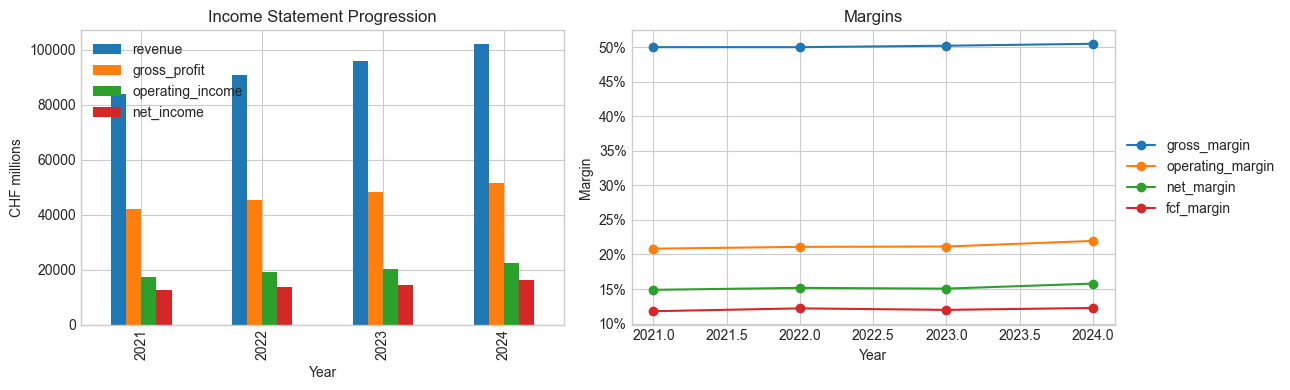

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

financials.plot(
    x="year",
    y=["revenue", "gross_profit", "operating_income", "net_income"],
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Income Statement Progression")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("CHF millions")
axes[0].legend(loc="upper left")

financials.plot(
    x="year",
    y=["gross_margin", "operating_margin", "net_margin", "fcf_margin"],
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Margins")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Margin")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.tight_layout()
plt.show()

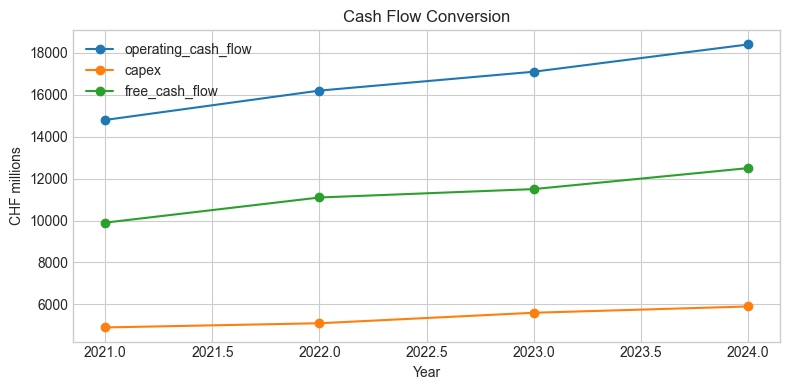

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

financials.plot(x="year", y=["operating_cash_flow", "capex", "free_cash_flow"], marker="o", ax=ax)
ax.set_title("Cash Flow Conversion")
ax.set_xlabel("Year")
ax.set_ylabel("CHF millions")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

## 5. Application

When reading a large consumer company such as Nestle, start with a few practical questions:

- Is revenue growing consistently?
- Are gross and operating margins stable?
- Does net income convert into free cash flow?
- Is leverage increasing faster than assets or equity?
- Are capital expenditures normal for the business model?

A high-quality defensive company usually has stable margins, positive free cash flow, and a balance sheet that does not depend on aggressive borrowing.

In [30]:
latest = financials.iloc[-1]
prior = financials.iloc[0]

revenue_cagr = (latest["revenue"] / prior["revenue"]) ** (1 / (latest["year"] - prior["year"])) - 1
fcf_conversion = latest["free_cash_flow"] / latest["net_income"]

print(f"Revenue CAGR: {revenue_cagr:.1%}")
print(f"Latest gross margin: {latest['gross_margin']:.1%}")
print(f"Latest operating margin: {latest['operating_margin']:.1%}")
print(f"Latest FCF conversion: {fcf_conversion:.1%}")
print(f"Latest debt/assets: {latest['debt_to_assets']:.1%}")

Revenue CAGR: 6.7%
Latest gross margin: 50.5%
Latest operating margin: 22.0%
Latest FCF conversion: 77.6%
Latest debt/assets: 54.6%


## 6. Reflection

- The income statement explains profitability, but not necessarily cash generation.
- The balance sheet explains financial position and funding structure.
- The cash flow statement shows whether accounting earnings translate into usable cash.
- The accounting identity `Assets = Liabilities + Equity` is the anchor of the whole system.
- In valuation, free cash flow quality matters more than reported growth alone.

Questions to answer after running the notebook:

1. Which metric changed the most over the sample period?
2. Did revenue growth improve or weaken profitability?
3. Would this company be easier or harder to value than a cyclical company? Why?